In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [2]:
import pandas as pd
import numpy as up
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/customer_churn_eda_raw.csv')
df.head()

df.head()
df.info()
df.isna().sum()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      120 non-null    object 
 1   gender           112 non-null    object 
 2   age              114 non-null    float64
 3   region           120 non-null    object 
 4   tenure           117 non-null    float64
 5   monthly_charges  120 non-null    int64  
 6   contract_type    120 non-null    object 
 7   churn            120 non-null    object 
 8   total_charges    117 non-null    float64
dtypes: float64(3), int64(1), object(5)
memory usage: 8.6+ KB


,0
customer_id,0
gender,8
age,6
region,0
tenure,3
monthly_charges,0
contract_type,0
churn,0
total_charges,3


In [3]:
df ["gender"].fillna ("Unknown", inplace=True)

/tmp/ipykernel_31454/1623721684.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df ["gender"].fillna ("Unknown", inplace=True)


In [4]:
df ["age"].fillna(df ["age"].median(), inplace=True)

/tmp/ipykernel_31454/2508090729.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df ["age"].fillna(df ["age"].median(), inplace=True)


In [5]:
df ["tenure"].fillna(0, inplace=True)

/tmp/ipykernel_31454/291793912.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df ["tenure"].fillna(0, inplace=True)


In [6]:
df["monthly_charges"] = df.groupby("contract_type") ["monthly_charges"] \
.transform(lambda x: x.fillna(x.mean()))

In [7]:
df ["total_charges"] = df ["monthly_charges"] * df ["tenure"]

In [16]:
df.isna().sum()

,0
customer_id,0
gender,0
age,0
region,0
tenure,0
monthly_charges,0
contract_type,0
churn,0
total_charges,0


In [17]:
df.describe()

,age,tenure,monthly_charges,total_charges
count,120.000000,120.000000,120.000000,120.000000
mean,37.841667,28.683333,473.091667,13312.333333
std,12.110309,17.477468,143.453093,8953.752278
min,18.000000,0.000000,200.000000,0.000000
25%,28.000000,14.000000,335.250000,5725.250000
50%,36.500000,26.000000,493.000000,12929.000000
75%,48.250000,44.500000,592.250000,19060.000000
max,59.000000,59.000000,697.000000,37072.000000


In [9]:
df.groupby("churn") ["monthly_charges"].mean()
df.groupby("contract_type") ["churn"].value_counts (normalize=True)

contract_type  churn
Monthly        No       0.611111
               Yes      0.388889
Quarterly      No       0.718750
               Yes      0.281250
Yearly         No       0.750000
               Yes      0.250000
Name: proportion, dtype: float64

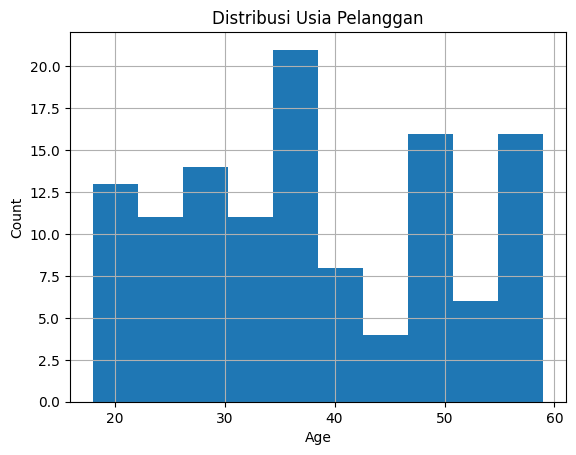

In [10]:
df ["age"].hist(bins=10)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Distribusi Usia Pelanggan")
plt.show()

In [11]:
df.groupby ("gender") ["churn"].value_counts (normalize=True).unstack()

churn,No,Yes
gender,,
Female,0.763636,0.236364
Male,0.649123,0.350877
Unknown,0.625000,0.375000


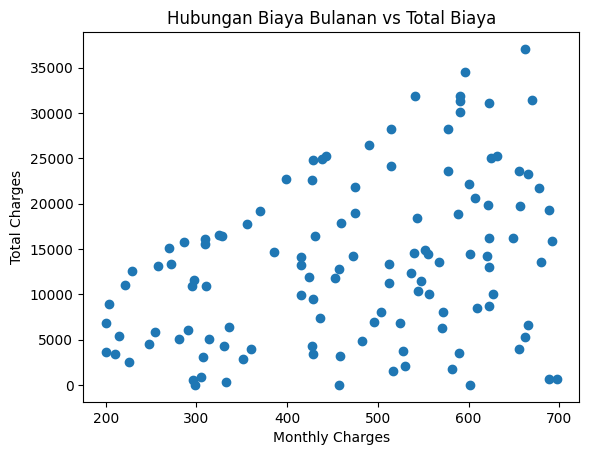

In [12]:
plt.scatter(df ["monthly_charges"], df["total_charges"])
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")
plt.title ("Hubungan Biaya Bulanan vs Total Biaya")
plt.show()


In [13]:
df.groupby ("churn") ["monthly_charges"].mean()

,monthly_charges
churn,
No,471.916667
Yes,475.833333


In [14]:
df.groupby("contract_type") ["churn"].value_counts(normalize=True).unstack()

churn,No,Yes
contract_type,,
Monthly,0.611111,0.388889
Quarterly,0.718750,0.281250
Yearly,0.750000,0.250000
